# Pulsed microwave spectrum analysis

Analyzes every `pulse_*ns` run saved by `pulsed_spectrum_test.ipynb` in `data/`: a CW carrier gated on/off by a 50% duty cycle square wave (AWG CH2) at `1 / period_ns`, captured on the E4403B.

**Expected from Fourier theory:** amplitude-modulating a carrier with an ideal 50% duty cycle square wave produces a comb of **only odd harmonics** of the chop frequency around the carrier (every even harmonic is exactly zero for a symmetric square wave), with the n-th harmonic's amplitude relative to the carrier given by `duty * sinc(n * duty)` (`sinc(x) = sin(pi x) / (pi x)`), i.e. falling off roughly as `1/n` with alternating sign (irrelevant once we look at power). We check each run against this in three ways and flag anything that doesn't match:

1. **Capture window centering** -- did the analyzer actually sweep `carrier +- span/2` as requested, or did it hit its own max frequency and slide the whole window down?
2. **Comb periodicity SNR** -- is there really a periodic comb in the trace at the expected `chop_freq_hz` spacing, or does it just look like noise?
3. **Odd/even harmonic suppression** -- are the even harmonics actually suppressed relative to the odd ones (as a true 50% duty square wave requires), or has the modulation stopped looking like a clean square wave?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TESTS_DIR = Path(r"C:\Users\codin\Documents\projects\diamonds\experiment\tests")
DATA_DIR = TESTS_DIR / "data"

WINDOW_SHIFT_THRESHOLD_HZ = 10e6
SNR_THRESHOLD = 15.0
GAP_THRESHOLD_DB = 10.0
N_HARMONICS = 10

## Load every run

In [2]:
def parse_metadata(path):
    metadata = {}
    for line in open(path):
        key, _, value = line.strip().partition("=")
        metadata[key] = value if key == "timestamp" else float(value)
    return metadata


def discover_pulse_runs(data_dir):
    folders = list(data_dir.glob("pulse_*ns"))
    period_of = lambda f: float(f.name[len("pulse_") : -len("ns")])
    return sorted(folders, key=period_of)


def load_pulse_run(folder):
    freqs_hz = np.load(folder / "freqs_hz.npy")
    power_dbm = np.load(folder / "power_dbm.npy")
    metadata = parse_metadata(folder / "metadata.txt")
    return {"name": folder.name, "freqs_hz": freqs_hz, "power_dbm": power_dbm, **metadata}


runs = [load_pulse_run(folder) for folder in discover_pulse_runs(DATA_DIR)]
print(f"loaded {len(runs)} runs: " + ", ".join(f"{r['period_ns']:g} ns" for r in runs))

loaded 28 runs: 10 ns, 15 ns, 15.5 ns, 15.7 ns, 15.9 ns, 16 ns, 17 ns, 20 ns, 21 ns, 22 ns, 25 ns, 27 ns, 30 ns, 40 ns, 50 ns, 60 ns, 70 ns, 80 ns, 90 ns, 100 ns, 120 ns, 125 ns, 150 ns, 200 ns, 500 ns, 1000 ns, 5000 ns, 7000 ns


## Diagnostics

In [3]:
def expected_harmonics_dbc(chop_freq_hz, duty_frac, n_max=N_HARMONICS):
    """Ideal on/off gate's harmonic frequencies (as offsets from the carrier)
    and their power relative to the carrier line, in dBc."""
    n = np.arange(-n_max, n_max + 1)
    n = n[n != 0]
    amplitude = duty_frac * np.abs(np.sinc(n * duty_frac))
    rel_dbc = 20 * np.log10(amplitude / duty_frac)
    return n, rel_dbc


def check_window_centering(run):
    """Flag when the analyzer's captured window isn't centered on the carrier
    as requested -- happens when carrier + span/2 exceeds the analyzer's own
    max frequency and it slides the whole window down instead of clipping it.
    """
    expected_start = run["carrier_hz"] - run["span_hz"] / 2
    start_shift_hz = run["freqs_hz"].min() - expected_start
    return abs(start_shift_hz) > WINDOW_SHIFT_THRESHOLD_HZ, start_shift_hz


def periodicity_snr(freqs_hz, power_dbm, chop_freq_hz):
    """Ratio of the FFT-of-the-trace's magnitude at the chop-frequency-spaced
    ripple periodicity to the typical background level elsewhere -- a real
    comb stands out here, noise doesn't."""
    freq_step_hz = freqs_hz[1] - freqs_hz[0]
    detrended = power_dbm - power_dbm.mean()
    fft_mag = np.abs(np.fft.rfft(detrended))
    fft_cycles_per_hz = np.fft.rfftfreq(len(detrended), d=freq_step_hz)
    expected_cycles_per_hz = 1 / chop_freq_hz
    peak_idx = np.argmin(np.abs(fft_cycles_per_hz - expected_cycles_per_hz))
    background = np.median(np.delete(fft_mag, [0, peak_idx]))
    return fft_mag[peak_idx] / background if background > 0 else float("inf")


def odd_even_gap_db(run, n_max=N_HARMONICS):
    """Mean measured level (dBc) of the odd vs. even harmonics that actually
    fall inside the captured frequency range, and how many dB the even ones
    sit below the odd ones -- a true 50% duty square wave should show a large
    positive gap (even harmonics nulled); a near-zero gap means the
    modulation doesn't look like a clean 50% duty square wave."""
    freqs_hz, power_dbm = run["freqs_hz"], run["power_dbm"]
    carrier_hz, chop_freq_hz = run["carrier_hz"], run["chop_freq_hz"]
    carrier_dbm = power_dbm[np.argmin(np.abs(freqs_hz - carrier_hz))]

    odd_levels, even_levels = [], []
    for n in range(-n_max, n_max + 1):
        if n == 0:
            continue
        f = carrier_hz + n * chop_freq_hz
        if not (freqs_hz.min() <= f <= freqs_hz.max()):
            continue
        rel_dbc = power_dbm[np.argmin(np.abs(freqs_hz - f))] - carrier_dbm
        (odd_levels if n % 2 else even_levels).append(rel_dbc)

    odd_mean = np.mean(odd_levels) if odd_levels else np.nan
    even_mean = np.mean(even_levels) if even_levels else np.nan
    return odd_mean, even_mean, odd_mean - even_mean


def diagnose_run(run):
    window_shifted, start_shift_hz = check_window_centering(run)
    snr = periodicity_snr(run["freqs_hz"], run["power_dbm"], run["chop_freq_hz"])
    odd_mean, even_mean, gap_db = odd_even_gap_db(run)
    flags = []
    if window_shifted:
        flags.append("capture window shifted off the carrier (hit analyzer max freq)")
    if snr < SNR_THRESHOLD:
        flags.append("comb not clearly distinguishable from noise")
    if not np.isnan(gap_db) and gap_db < GAP_THRESHOLD_DB:
        flags.append("even harmonics not suppressed -- doesn't look like 50% duty")
    run.update(
        window_shifted=window_shifted,
        start_shift_hz=start_shift_hz,
        periodicity_snr=snr,
        odd_mean_dbc=odd_mean,
        even_mean_dbc=even_mean,
        even_odd_gap_db=gap_db,
        flags=flags,
    )
    return run


runs = [diagnose_run(run) for run in runs]

## Summary table

In [4]:
def print_summary(runs):
    header = (
        f"{'period [ns]':>11} {'chop [MHz]':>11} {'SNR':>7} "
        f"{'win shift [MHz]':>16} {'odd/even gap [dB]':>18}  flags"
    )
    print(header)
    for run in runs:
        print(
            f"{run['period_ns']:>11g} {run['chop_freq_hz']/1e6:>11.3f} "
            f"{run['periodicity_snr']:>7.1f} {run['start_shift_hz']/1e6:>16.2f} "
            f"{run['even_odd_gap_db']:>18.1f}  " + ("; ".join(run["flags"]) or "-")
        )


print_summary(runs)

period [ns]  chop [MHz]     SNR  win shift [MHz]  odd/even gap [dB]  flags
         10     100.000     4.1          -400.00               -0.2  capture window shifted off the carrier (hit analyzer max freq); comb not clearly distinguishable from noise; even harmonics not suppressed -- doesn't look like 50% duty
         15      66.667     9.5           -66.67                0.1  capture window shifted off the carrier (hit analyzer max freq); comb not clearly distinguishable from noise; even harmonics not suppressed -- doesn't look like 50% duty
       15.5      64.516     9.5           -45.16                0.5  capture window shifted off the carrier (hit analyzer max freq); comb not clearly distinguishable from noise; even harmonics not suppressed -- doesn't look like 50% duty
       15.7      63.694    10.0           -36.94               -0.2  capture window shifted off the carrier (hit analyzer max freq); comb not clearly distinguishable from noise; even harmonics not suppressed -- 

## Every spectrum vs. the ideal 50% duty comb

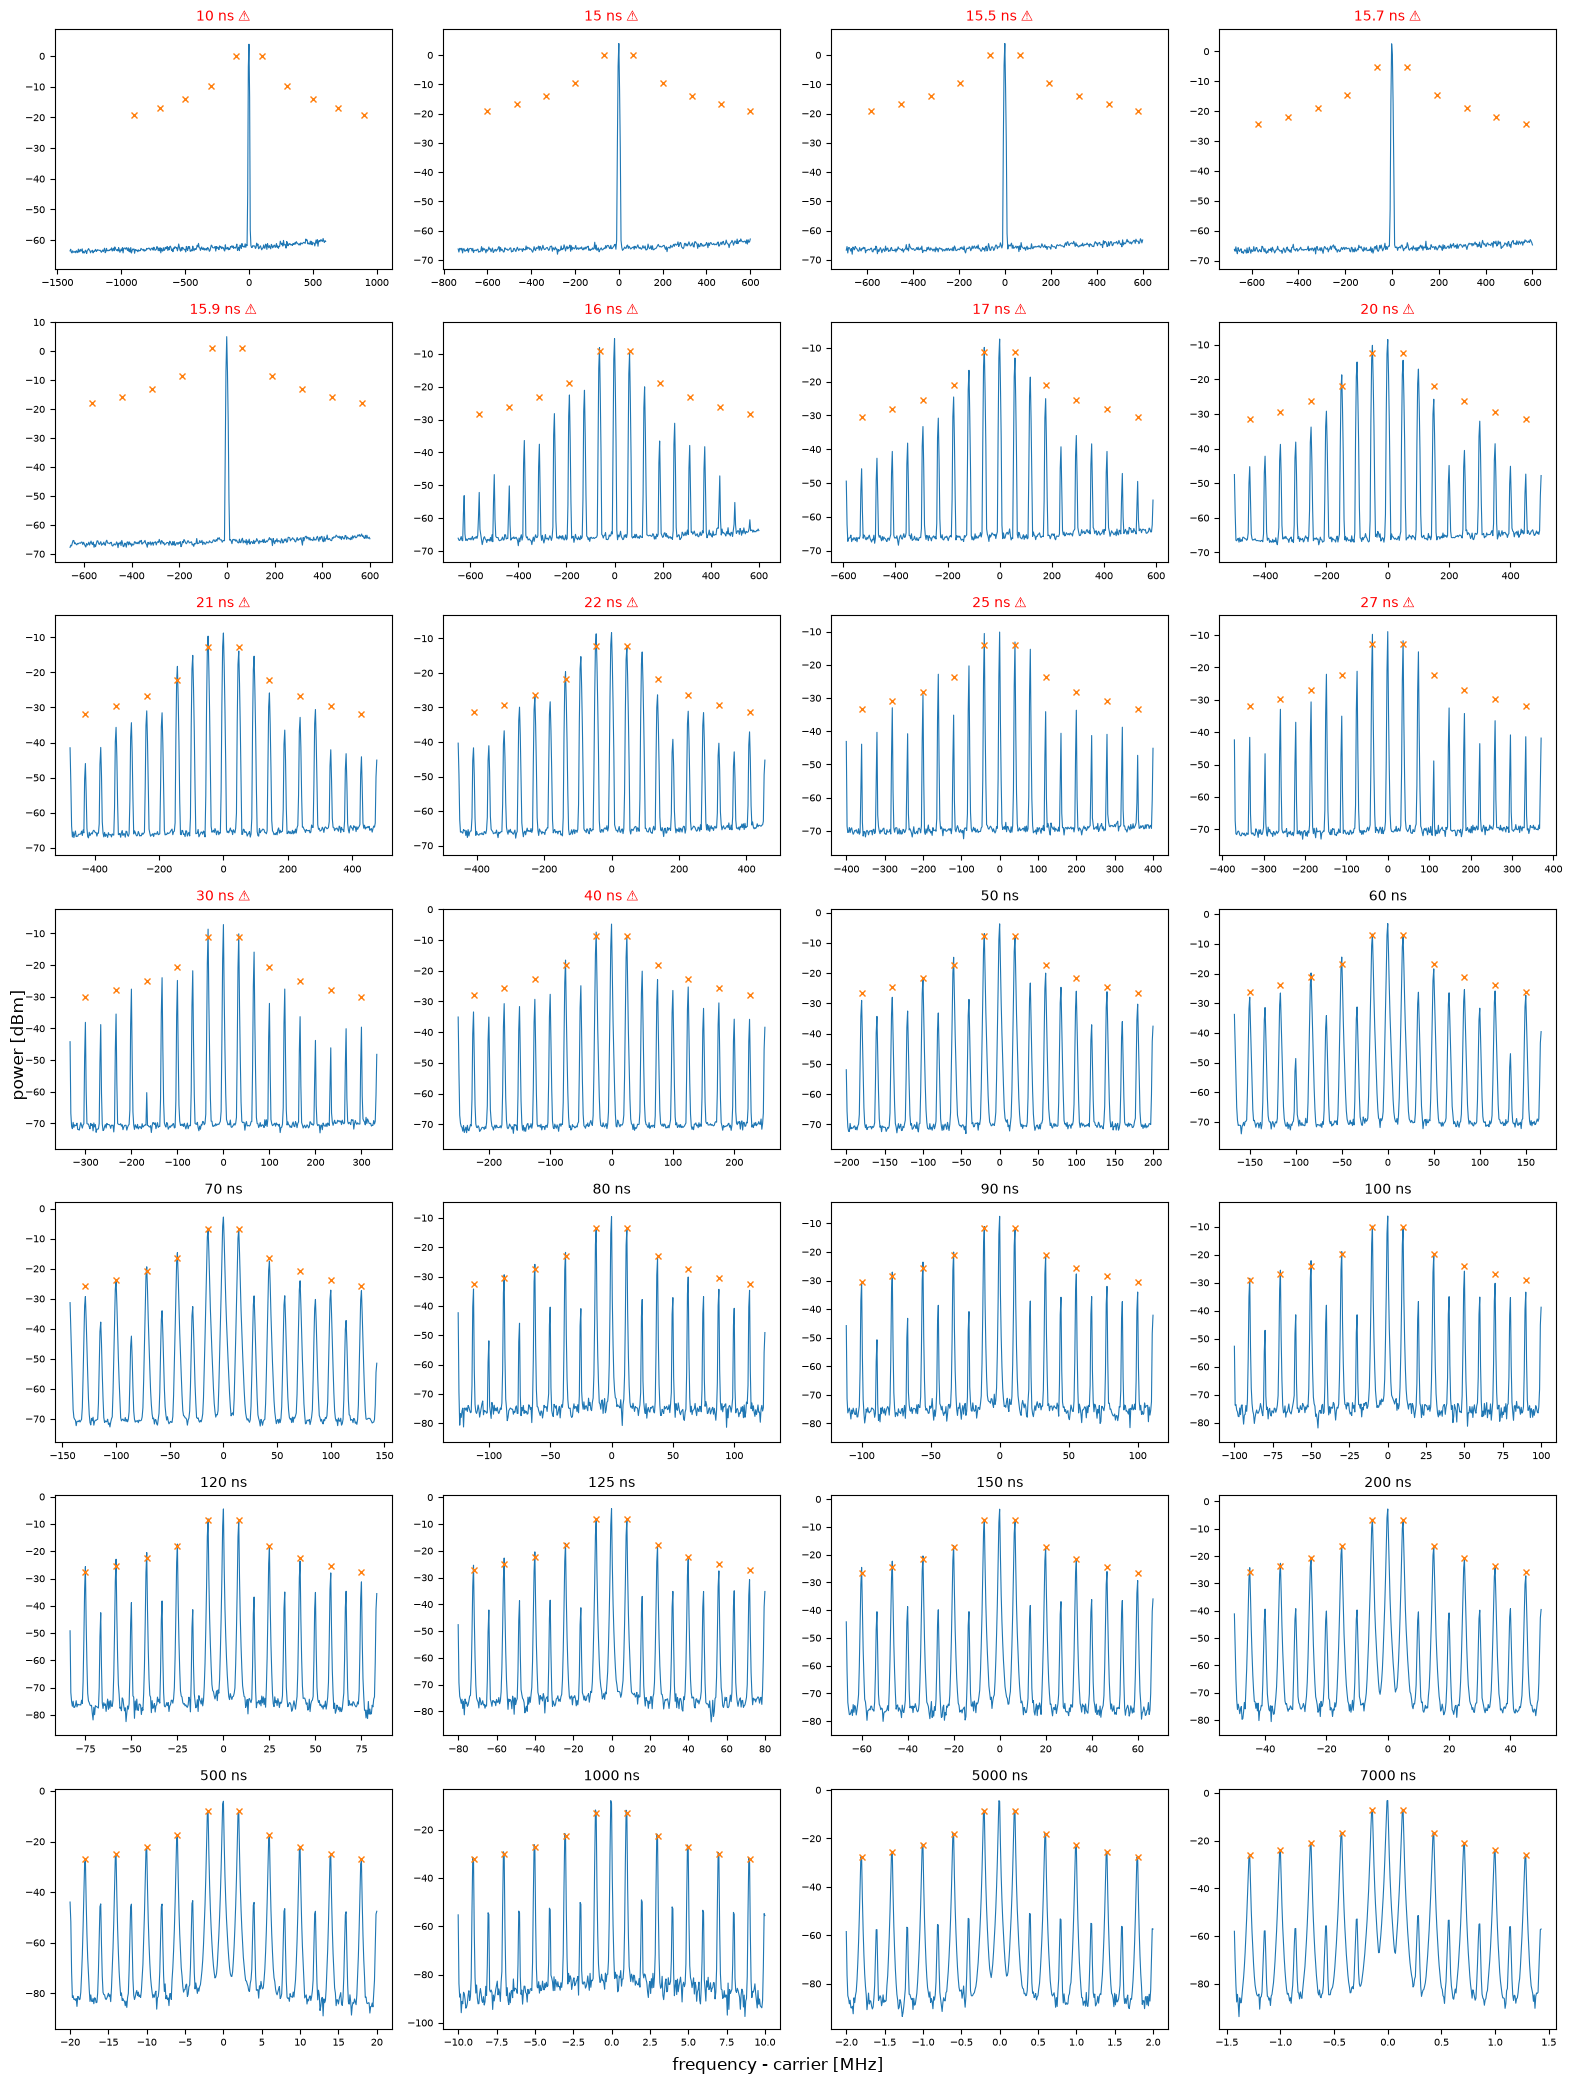

In [5]:
def plot_run_grid(runs, ncols=4):
    nrows = -(-len(runs) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, run in zip(axes, runs):
        freqs_mhz = (run["freqs_hz"] - run["carrier_hz"]) / 1e6
        ax.plot(freqs_mhz, run["power_dbm"], color="C0", lw=0.8)

        n_harm, rel_dbc = expected_harmonics_dbc(run["chop_freq_hz"], run["duty_cycle_pct"] / 100)
        carrier_dbm = run["power_dbm"][np.argmin(np.abs(run["freqs_hz"] - run["carrier_hz"]))]
        expected_freqs_mhz = n_harm * run["chop_freq_hz"] / 1e6
        ax.plot(expected_freqs_mhz, carrier_dbm + rel_dbc, "x", color="C1", ms=4)

        # Ideal-model null markers (theoretical even harmonics) land at ~-300
        # dBc from float roundoff in sinc(), not real data -- zoom to the
        # MEASURED trace's own range so they don't blow up the y-axis.
        y_margin = 5
        ax.set_ylim(run["power_dbm"].min() - y_margin, run["power_dbm"].max() + y_margin)

        flagged = bool(run["flags"])
        ax.set_title(
            f"{run['period_ns']:g} ns" + (" ⚠" if flagged else ""),
            color="red" if flagged else "black",
            fontsize=10,
        )
        ax.tick_params(labelsize=7)

    for ax in axes[len(runs):]:
        ax.axis("off")

    fig.supxlabel("frequency - carrier [MHz]")
    fig.supylabel("power [dBm]")
    fig.tight_layout()
    return fig, axes


plot_run_grid(runs)
plt.show()

## Odd/even harmonic suppression vs. period

The key physical result: how cleanly each run's modulation matches an ideal 50% duty square wave (large gap = clean; near-zero gap = doesn't look like 50% duty), as a function of pulse period.

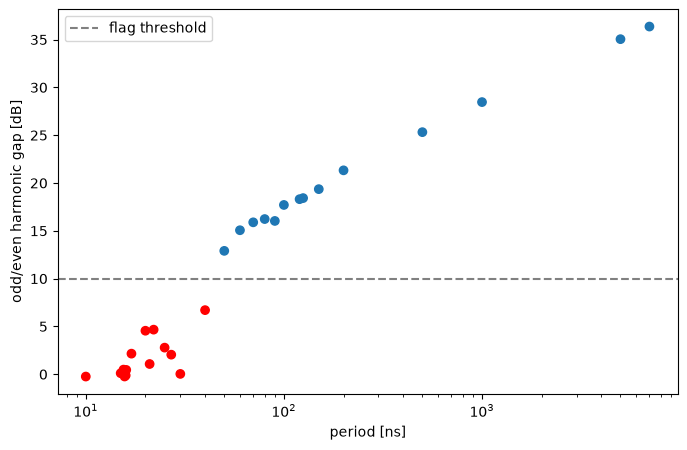

In [6]:
def plot_gap_vs_period(ax, runs):
    periods_ns = [run["period_ns"] for run in runs]
    gaps_db = [run["even_odd_gap_db"] for run in runs]
    colors = ["red" if run["flags"] else "C0" for run in runs]
    ax.scatter(periods_ns, gaps_db, c=colors)
    ax.axhline(GAP_THRESHOLD_DB, linestyle="--", color="gray", label="flag threshold")
    ax.set_xscale("log")
    ax.set_xlabel("period [ns]")
    ax.set_ylabel("odd/even harmonic gap [dB]")
    ax.legend()
    return ax


fig, ax = plt.subplots(figsize=(8, 5))
plot_gap_vs_period(ax, runs)
plt.show()

## Flagged points

In [7]:
flagged_runs = [run for run in runs if run["flags"]]
if not flagged_runs:
    print("no runs flagged")
else:
    print(f"{len(flagged_runs)}/{len(runs)} runs flagged:\n")
    for run in flagged_runs:
        print(f"{run['period_ns']:g} ns:")
        for flag in run["flags"]:
            print(f"  - {flag}")

14/28 runs flagged:

10 ns:
  - capture window shifted off the carrier (hit analyzer max freq)
  - comb not clearly distinguishable from noise
  - even harmonics not suppressed -- doesn't look like 50% duty
15 ns:
  - capture window shifted off the carrier (hit analyzer max freq)
  - comb not clearly distinguishable from noise
  - even harmonics not suppressed -- doesn't look like 50% duty
15.5 ns:
  - capture window shifted off the carrier (hit analyzer max freq)
  - comb not clearly distinguishable from noise
  - even harmonics not suppressed -- doesn't look like 50% duty
15.7 ns:
  - capture window shifted off the carrier (hit analyzer max freq)
  - comb not clearly distinguishable from noise
  - even harmonics not suppressed -- doesn't look like 50% duty
15.9 ns:
  - capture window shifted off the carrier (hit analyzer max freq)
  - comb not clearly distinguishable from noise
  - even harmonics not suppressed -- doesn't look like 50% duty
16 ns:
  - capture window shifted off the c